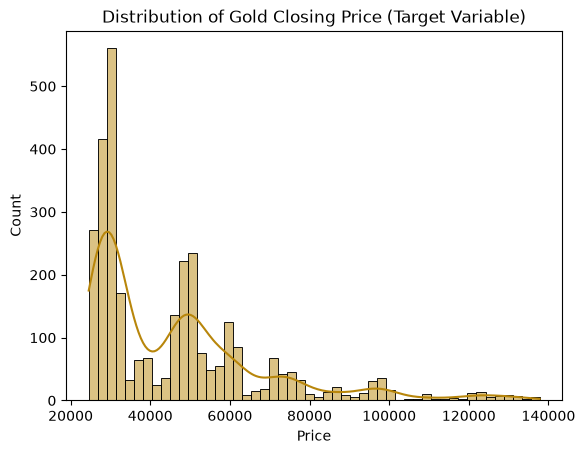

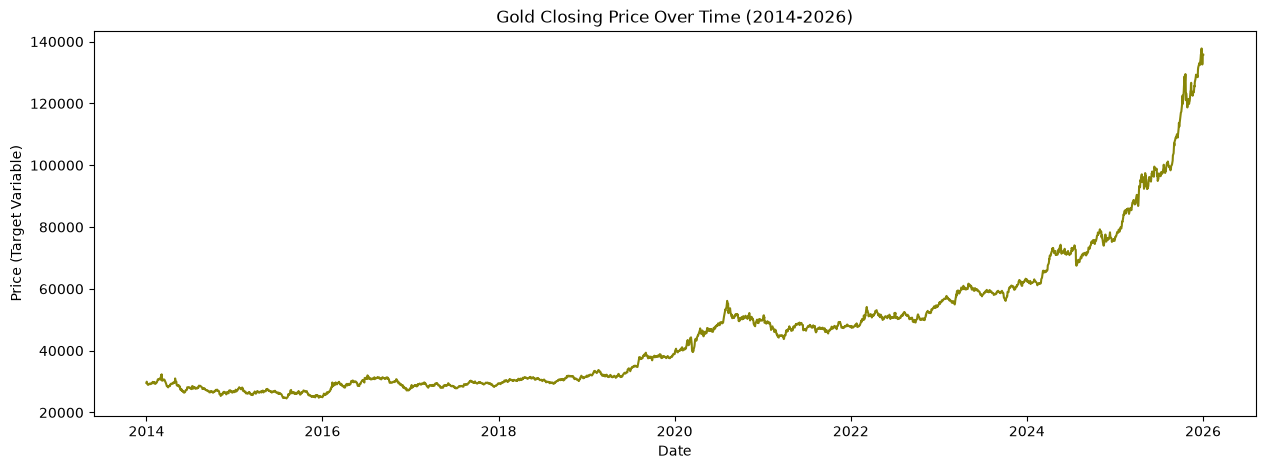

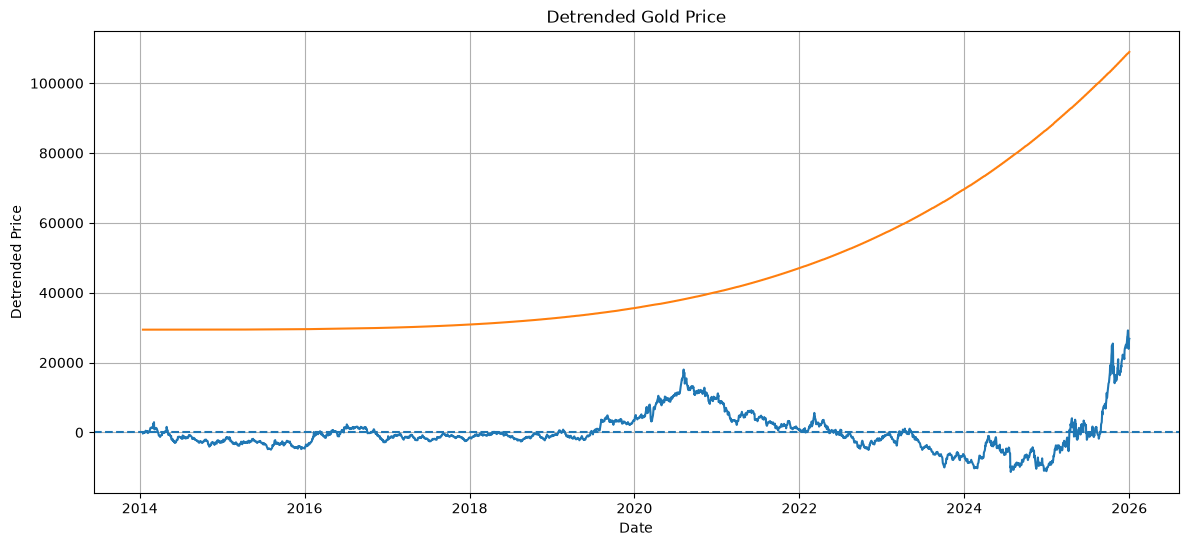

/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


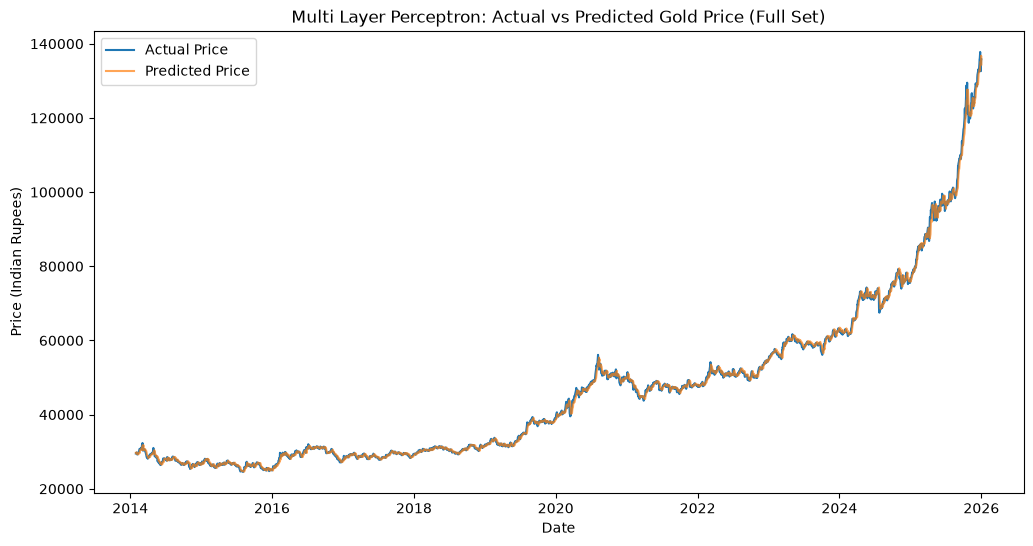

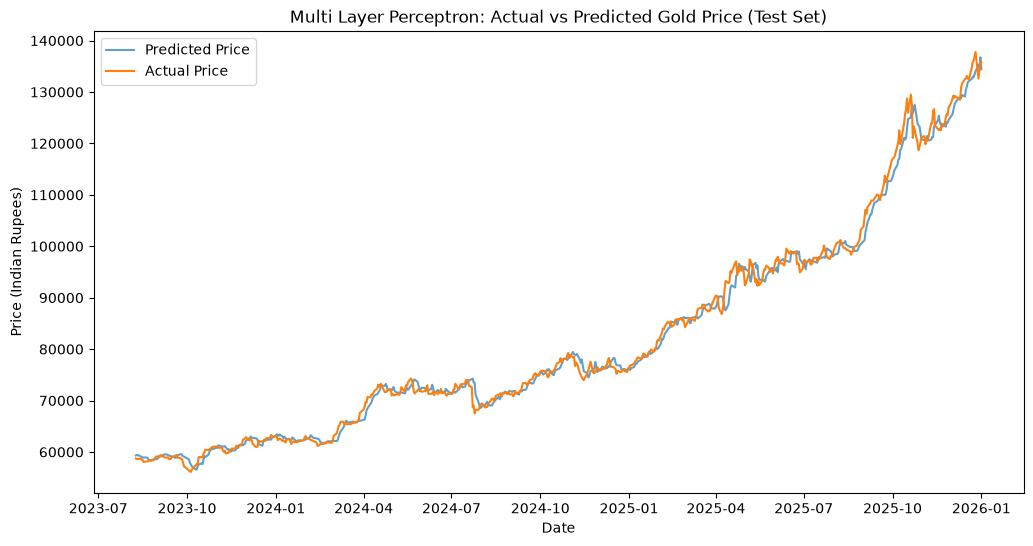

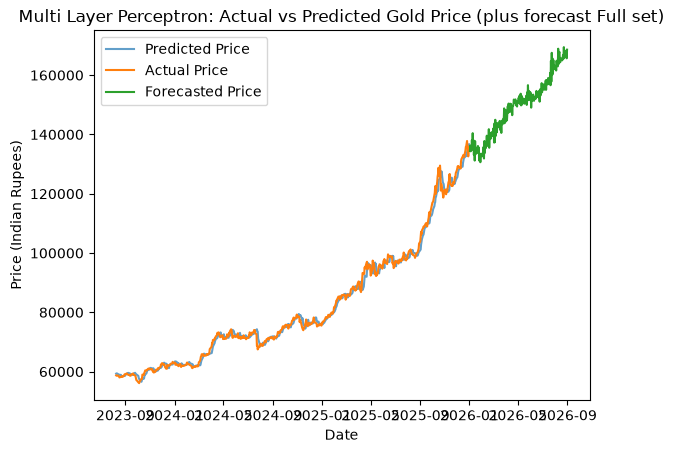

In [3]:
#Import libraries
#!mamba install pandas
#!mamba install numpy
#!mamba install seaborn
#!mamba install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Display all columns
pd.set_option('display.max_columns', None)

# Read the CSV file
df = pd.read_csv('Gold Price.csv')

# Convert date format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (ensure correct chronological order)
df = df.sort_values('Date').reset_index(drop=True)

sns.histplot(df ['Price'], kde=True, bins=50, color='#B8860B')
plt.title('Distribution of Gold Closing Price (Target Variable)')
plt.xlabel('Price')
plt.show()

plt.figure(figsize=(15,5))
plt.plot(df['Date'], df ['Price'], color='#888608')
plt.title('Gold Closing Price Over Time (2014-2026)')
plt.xlabel('Date')
plt.ylabel('Price (Target Variable)')
plt.show()

# 1. Check for missing values (verification)

# 2. Check for duplicate values

# 3. Extract time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Quarter'] = df['Date'].dt.quarter

# 4. Create target variable (tomorrow's closing price)
df['Target'] = df['Price'].shift(-1)  # Predicting tomorrow's price
df['Return'] = df['Price'].pct_change()  # Predicting tomorrow's price

# 5. Create lagged features
for lag in [1, 2, 3, 5, 10]:
    df[f'Price_Lag_{lag}'] = df['Price'].shift(lag)
    df[f'Volume_Lag_{lag}'] = df['Volume'].shift(lag)
    df[f'Return_Lag_{lag}'] = df['Return'].shift(lag)

# 6. Create rolling statistical features
for window in [3, 5, 10]:
    df[f'MA_{window}'] = df['Price'].rolling(window=window).mean()
    df[f'Std_{window}'] = df['Price'].rolling(window=window).std()

### Re-check missing values after feature engineering

# 7. Create price-derived features
df['Daily_Range'] = df['High'] - df['Low']
df['Daily_Range_Pct'] = (df['High'] - df['Low']) / df['Low'] * 100
df['Price_Open_Ratio'] = df['Price'] / df['Open']

# 8. Outlier detection using IQR (moved BEFORE dropna/save so the flag survives)
lo = df["Daily_Range_Pct"].quantile(0.25)
hi = df["Daily_Range_Pct"].quantile(0.75)
inter = hi - lo
lbound = lo - (inter * 1.5)
hbound = hi + (inter * 1.5)
# Breakdown by year to check whether outliers cluster around known high-volatility periods
# 11. Flag extreme days instead of removing them
df['Is_Extreme_Day'] = ((df['Daily_Range_Pct'] > hbound) |
                         (df['Daily_Range_Pct'] < lbound)).astype(int)

# 12. Drop rows containing null values (since shift and rolling operations produce NaNs)
df_clean = df.dropna()

# 0. REMOVE THE TREND FIRST OR MODEL GEtS CONFUSED
x = np.arange(len(df_clean)).reshape(-1, 1)
y = df_clean['Price'].values
poly = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(x)
trend_model = LinearRegression()
trend_model.fit(x_poly, y)
trend = trend_model.predict(x_poly)
df_clean['Trend'] = trend
df_clean['DPrice'] = df_clean['Price'] - df_clean['Trend']

plt.figure(figsize=(14, 6))

plt.plot(
    df_clean['Date'],
    df_clean['DPrice']
)
plt.plot(
    df_clean['Date'],
    df_clean['Trend']
)

plt.axhline(0, linestyle='--')

plt.xlabel('Date')
plt.ylabel('Detrended Price')
plt.title('Detrended Gold Price')
plt.grid(True)
plt.show()
##Now replace everything
for lag in [1, 2, 3, 5, 10]:
    df_clean[f'Price_Lag_{lag}'] = df_clean['DPrice'].shift(lag)
for window in [3, 5, 10]:
    df_clean[f'MA_{window}'] = df_clean['DPrice'].rolling(window=window).mean()
    df_clean[f'Std_{window}'] = df_clean['DPrice'].rolling(window=window).std()

##run this again
df_clean = df_clean.dropna()

# Reset index
df_clean = df_clean.reset_index(drop=True)

# 13. Save the cleaned data
df_clean.to_csv('Gold_Price_Cleaned.csv', index=False)

################
k = MLPRegressor(
    hidden_layer_sizes=(11,),
    max_iter=20,
    early_stopping = True,
    random_state=42
)#testing with one hidden layer
f = df_clean.loc[:,df_clean.columns != 'Date']#clear date to make training possible
f['logPrice'] = np.log(f.Price)
f['logOpen'] = np.log(f.Open)
X = f.loc[:len(f)-2,['Price_Lag_1','Price_Lag_2','Price_Lag_3',
                     'MA_3','MA_5','MA_10',
                     'Return_Lag_1','Return_Lag_2',
                     'Return_Lag_3','Return_Lag_5']]#Use future derived values instead so It could predict even without prior knowedle
Y = f.loc[1:,'DPrice']
YPeek = f.loc[1:,'Price']
YT = f.loc[1:,'Trend']
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42,shuffle=False)
practice,trainer, y_trend, y_probably = train_test_split(df_clean.Date[1:],
                                                         YT, test_size=0.2, random_state=42,shuffle=False)
k.fit(X_train,y_train)

isit = k.predict(X)
isit = isit + YT
mae = mean_absolute_error(YPeek,isit)
mse = mean_squared_error(YPeek, isit)
rmse = np.sqrt(mse)
r2 = r2_score(YPeek, isit)
plt.figure(figsize=(12, 6))
plt.plot(df_clean.loc[1:,'Date'], YPeek.values, label="Actual Price", linewidth=1.5)
plt.plot(df_clean.loc[1:,'Date'], isit, label="Predicted Price",
          linewidth=1.5, alpha=0.7)
plt.title("Multi Layer Perceptron: Actual vs Predicted Gold Price (Full Set)")
plt.xlabel("Date")
plt.ylabel("Price (Indian Rupees)")
plt.legend()
plt.savefig("full.png", dpi=150)
plt.show()

isit = k.predict(X_test)
isit = isit+y_probably
mae = mean_absolute_error(y_test+y_probably,isit)
mse = mean_squared_error(y_test+y_probably, isit)
rmse = np.sqrt(mse)
r2 = r2_score(y_test+y_probably, isit)
plt.figure(figsize=(12, 6))
plt.plot(trainer.values, isit, label="Predicted Price",
          linewidth=1.5, alpha=0.7)
plt.plot(trainer.values, (y_test.values+y_probably.values), label="Actual Price", linewidth=1.5)
plt.title("Multi Layer Perceptron: Actual vs Predicted Gold Price (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price (Indian Rupees)")
plt.legend()
plt.savefig("result.png", dpi=150)
plt.show()
##Residuals for noise
residuals = y_test +y_probably- isit

##Predicting stuff
rng = np.random.default_rng(42)
fture = pd.DataFrame({
    'Date': pd.date_range(start='2026-01-02', end='2026-08-31')
})
price = list(df_clean['Price'])
dprice = list(df_clean['DPrice'])
retrn = list(df_clean['Return'])
fture['Year'] = fture['Date'].dt.year
fture['Month'] = fture['Date'].dt.month
fture['Day'] = fture['Date'].dt.day
future = fture.loc[:,fture.columns != 'Date']#clear date to make training possible
future_x = np.arange(
    len(df_clean) + len(future)
).reshape(-1, 1)

future_x_poly = poly.transform(future_x)
Trending = trend_model.predict(future_x_poly)
df_clean['Trend'] = Trending[:len(df_clean)]
future['Trend'] = Trending[len(df_clean):]
for i in range(len(future)):
    future.at[i, 'Price_Lag_1'] = dprice[-1]
    future.at[i, 'Price_Lag_2'] = dprice[-2]
    future.at[i, 'Price_Lag_3'] = dprice[-3]
    future.at[i, 'Price_Lag_5'] = dprice[-5]

    future.at[i, 'MA_3'] = np.mean(dprice[-3:])
    future.at[i, 'MA_5'] = np.mean(dprice[-5:])
    future.at[i, 'MA_10'] = np.mean(dprice[-10:])
    
    future.at[i, 'Return_Lag_1'] = retrn[-1]
    future.at[i, 'Return_Lag_2'] = retrn[-2]
    future.at[i, 'Return_Lag_3'] = retrn[-3]
    future.at[i, 'Return_Lag_5'] = retrn[-5]

    # One-row input in the SAME column order as training
    test = future.loc[[i], [
        'Price_Lag_1', 'Price_Lag_2', 'Price_Lag_3', 
        'MA_3', 'MA_5', 'MA_10',
        'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5',
    ]]
    d = k.predict(test)[0] + (rng.choice(residuals))
    n = d+future.at[i,'Trend'] 
    r = (n-price[-1])/price[-1]
    future.at[i, 'DPrice'] = d
    future.at[i, 'Price'] = n
    future.at[i, 'Return'] = r
    #If I don't do this it can't be automated
    dprice.append(d)
    price.append(n)
    retrn.append(r)

future['Date'] = fture['Date']
future = future[df_clean.columns.intersection(future.columns)]
combined = pd.concat(
    [df_clean, future],
    ignore_index=True
)
plt.plot(trainer.values, isit, label="Predicted Price",
          linewidth=1.5, alpha=0.7)
plt.plot(trainer.values, (y_test.values+y_probably.values), label="Actual Price", linewidth=1.5)
plt.plot(
    future['Date'],
    future['Price'],
    label="Forecasted Price"
)
plt.title("Multi Layer Perceptron: Actual vs Predicted Gold Price (plus forecast Full set)")
plt.xlabel("Date")
plt.ylabel("Price (Indian Rupees)")
plt.legend()
plt.savefig("forecast.png", dpi=150)
plt.show()

0        29425.493305
1        29425.493305
2        29425.493310
3        29425.493322
4        29425.493346
            ...      
3077    107610.871810
3078    107706.423856
3079    107802.063098
3080    107897.789587
3081    107993.603376
Name: Trend, Length: 3082, dtype: float64
0      108089.504518
1      108185.493066
2      108281.569072
3      108377.732591
4      108473.983673
           ...      
237    133402.492277
238    133520.721588
239    133639.051328
240    133757.481556
241    133876.012328
Name: Trend, Length: 242, dtype: float64


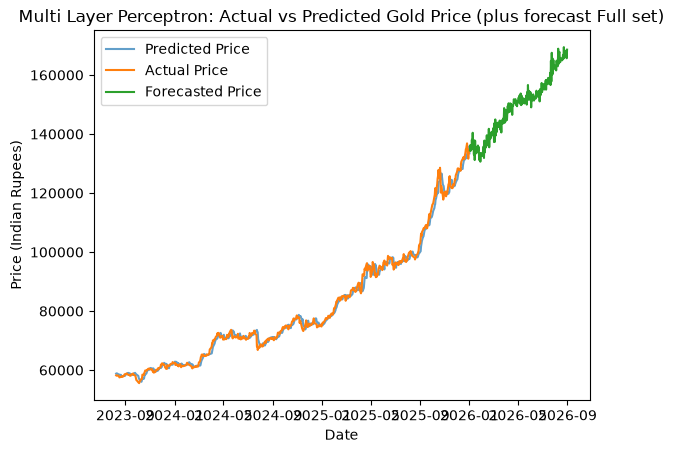

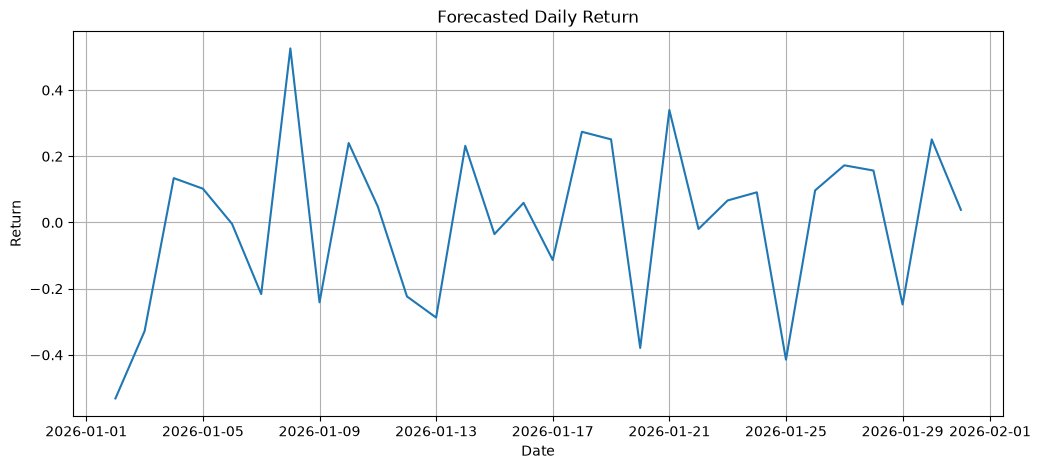

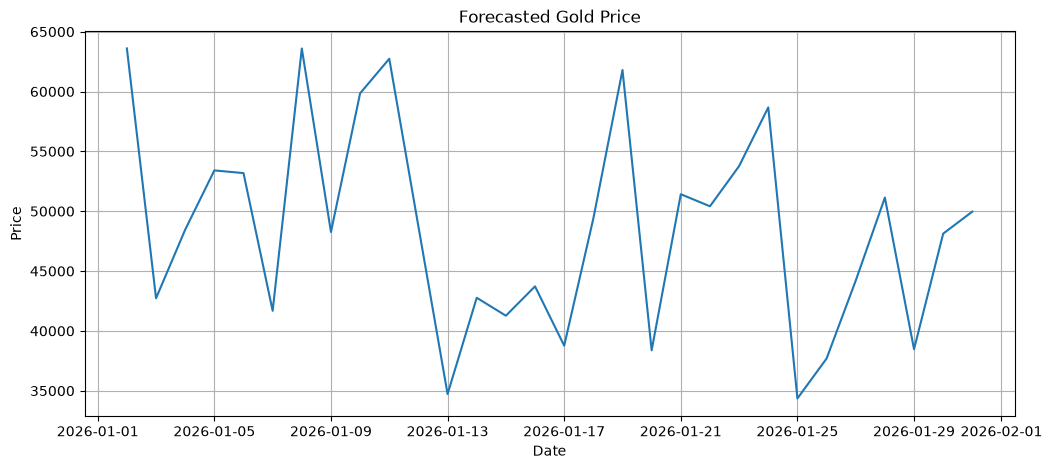

In [260]:
plt.figure(figsize=(12, 5))
plt.plot(future['Date'], future['Return'])
plt.title("Forecasted Daily Return")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(future['Date'], future['Price'])
plt.title("Forecasted Gold Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

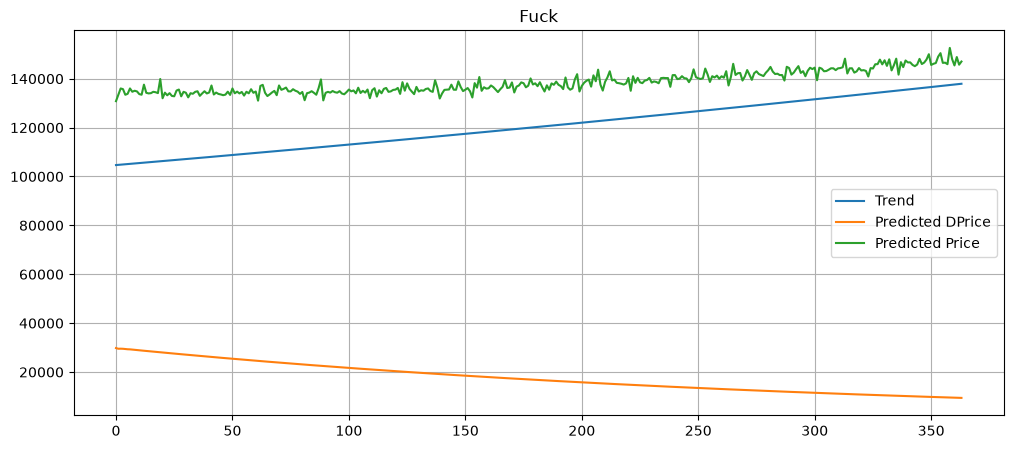

In [334]:
plt.figure(figsize=(12, 5))
plt.plot(future['Trend'], label='Trend')
plt.plot(future['DPrice'], label='Predicted DPrice')
plt.plot(future['Price'], label='Predicted Price')
plt.legend()
plt.title('Fuck')
plt.grid(True)
plt.show()